In [20]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sn

In [21]:
# 1. Load dataset
df = pd.read_csv('diabetes_dataset.csv')
print("Initial data shape:", df.shape)
print(df.head())

Initial data shape: (100000, 16)
   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes  
0           never  27.32

In [22]:
# 2. Drop unneeded columns
df.drop(columns=[
    'year','location',
    'race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other',
    'smoking_history'
], inplace=True)
print("After dropping columns:", df.shape)


After dropping columns: (100000, 8)


In [23]:
# 3. Encode gender
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])
print("Label Encoding Mapping:", dict(zip(encoder.classes_, range(len(encoder.classes_)))))

Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [24]:
# 4. Drop duplicates
df.drop_duplicates(inplace=True)
print("After dropping duplicates:", df.shape)

After dropping duplicates: (91313, 8)


In [25]:
# 5. Remove 'Other' gender (encoded as 2)
df = df[df['gender'] != 2]
print("After removing 'Other' gender:", df.shape)

After removing 'Other' gender: (91295, 8)


In [26]:
# 6. Normalize numeric columns to [0,1]
cols_to_normalize = ['age','bmi','hbA1c_level','blood_glucose_level']
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])
print("After normalization:")
print(df[cols_to_normalize].tail())

After normalization:
            age       bmi  hbA1c_level  blood_glucose_level
99995  0.411912  0.130719     0.545455             0.045455
99996  1.000000  0.311041     0.400000             0.090909
99997  0.574575  0.304739     0.490909             0.354545
99998  0.637137  0.225023     0.454545             0.340909
99999  0.161662  0.083450     0.272727             0.045455


In [27]:
# 7. Prepare features and target
X = df.drop(columns=['diabetes'])
y = df['diabetes']

In [28]:
# 8. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/test split:", X_train.shape, X_test.shape)

Train/test split: (73036, 7) (18259, 7)


In [29]:
# 9. Balance training set with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_balanced.shape)

After SMOTE: (132562, 7)


In [30]:
# 10. Instantiate and train KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance')
knn.fit(X_train_balanced, y_train_balanced)

KNeighborsClassifier(metric='manhattan', weights='distance')

In [31]:
# 11. Predict on test set
y_pred = knn.predict(X_test)

In [32]:
# 12. Evaluation metrics
print("\n=== KNN WITHOUT INTERACTIONS (k=5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


=== KNN WITHOUT INTERACTIONS (k=5) ===
Accuracy: 0.9240922284900597
Precision: 0.5653862753560639
Recall: 0.7756068679692125
F1-score: 0.654018971542686

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96     16570
           1       0.57      0.78      0.65      1689

    accuracy                           0.92     18259
   macro avg       0.77      0.86      0.81     18259
weighted avg       0.94      0.92      0.93     18259

Confusion Matrix:
 [[15563  1007]
 [  379  1310]]


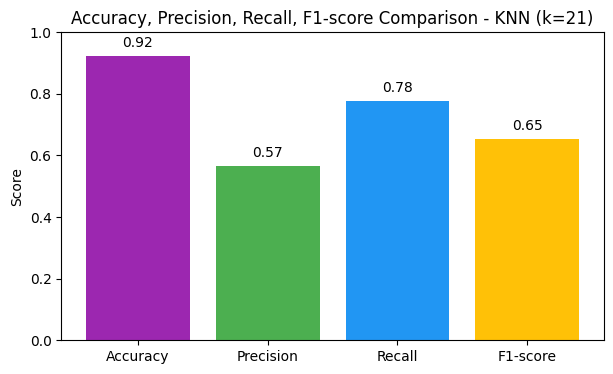

In [38]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.figure(figsize=(7,4))
bars = plt.bar(metrics, scores, color=['#9C27B0', '#4CAF50', '#2196F3', '#FFC107'])
plt.ylim([0, 1])
plt.title('Accuracy, Precision, Recall, F1-score Comparison - KNN (k=21)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')
plt.ylabel('Score')
plt.show()

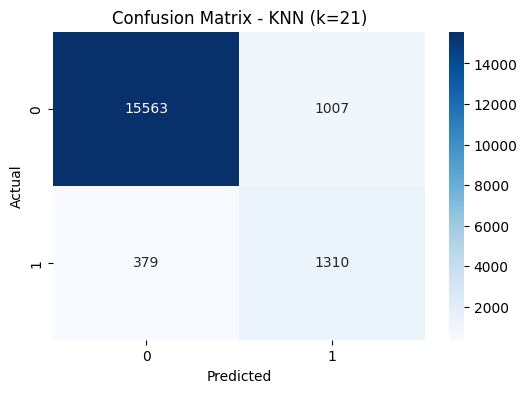

In [35]:


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN (k=21)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



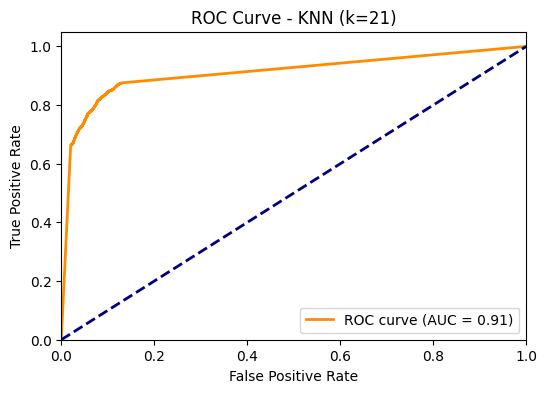

AUC: 0.9094076013882294


In [36]:

y_probs = knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (k=21)')
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]))
